In [26]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_ROOT = '/content/drive/MyDrive/casting_product_image_data/casting_data/casting_data'

print("Dataset root set to:", DATASET_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset root set to: /content/drive/MyDrive/casting_product_image_data/casting_data/casting_data


In [27]:

# Data set upload
DATASET_ROOT = '/content/drive/MyDrive/casting_product_image_data/casting_data/casting_data'

# Verify ki path sahi hai ya nahi
if os.path.exists(os.path.join(DATASET_ROOT, 'train')):
    print(f" Train folder finded: {os.path.join(DATASET_ROOT, 'train')}")
else:
    print(f" ERROR: Train folder nahi mila. Please DATASET_ROOT sahi karein.")

if os.path.exists(os.path.join(DATASET_ROOT, 'test')):
    print(f" Test folder finded: {os.path.join(DATASET_ROOT, 'test')}")
else:
    print(f"ERROR: Test folder not found")

 Train folder finded: /content/drive/MyDrive/casting_product_image_data/casting_data/casting_data/train
 Test folder finded: /content/drive/MyDrive/casting_product_image_data/casting_data/casting_data/test


In [28]:
#  Copy dataset to local Colab VM for super-fast
import shutil

SOURCE_PATH = DATASET_ROOT
LOCAL_PATH = '/content/casting_data'

if os.path.exists(LOCAL_PATH):
    print(f" Local dataset already exists at '{LOCAL_PATH}'. Skipping copy.")
else:
    print(f"   Source: {SOURCE_PATH}")
    print(f"   Destination: {LOCAL_PATH}")

    # Copy entire folder
    shutil.copytree(SOURCE_PATH, LOCAL_PATH)
    print("✅ Copy complete! Dataset is now on fast local storage.")

# Verify local copy
if os.path.exists(os.path.join(LOCAL_PATH, 'train')):
    print(f" Local train: {os.path.join(LOCAL_PATH, 'train')}")
if os.path.exists(os.path.join(LOCAL_PATH, 'test')):
    print(f" Local test: {os.path.join(LOCAL_PATH, 'test')}")

 Local dataset already exists at '/content/casting_data'. Skipping copy.
 Local train: /content/casting_data/train
 Local test: /content/casting_data/test


In [43]:
# import reqired Libraries au
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow version:", tf.__version__)

IMAGE_SIZE = (224, 224)      # Visual detail
BATCH_SIZE = 32              # Memory , Training Stability
MAX_EPOCHS = 25              # Maximum epochs
LEARNING_RATE = 0.001
DROPOUT_RATE = 0.40

# Local paths
print(f"Train Path: {LOCAL_TRAIN}")
print(f"Val Path: {LOCAL_VAL}")
print(f"Test Path: {LOCAL_TEST}")

TensorFlow version: 2.20.0
Train Path: /content/casting_data/train
Val Path: /content/casting_data/validation
Test Path: /content/casting_data/test


In [31]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    LOCAL_TRAIN, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    label_mode="binary", shuffle=True, seed=42
)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    LOCAL_VAL, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    label_mode="binary", shuffle=False
)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    LOCAL_TEST, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    label_mode="binary", shuffle=False
)

# Save class
class_names = train_dataset.class_names
num_train = len(train_dataset)
num_val = len(validation_dataset)
num_test = len(test_dataset)

# Now apply caching
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(AUTOTUNE)

print("\n Class names:", class_names)
print(f"Training batches   : {num_train}")
print(f"Validation batches : {num_val}")
print(f"Test batches       : {num_test}")
print(" Caching enabled")

Found 6636 files belonging to 2 classes.
Found 1328 files belonging to 2 classes.
Found 715 files belonging to 2 classes.

📋 Class names: ['def_front', 'ok_front']
Training batches   : 208
Validation batches : 42
Test batches       : 23
✅ Caching enabled!


data augumentation

In [32]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10)
])


In [33]:
model = models.Sequential([
    layers.Input(shape=(224,224,3)),
    data_augmentation,
    layers.Rescaling(1./255),
    layers.Conv2D(32,3,activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128,3,activation='relu'),
    layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(DROPOUT_RATE),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)


Collback

In [35]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                     restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                         patience=2, verbose=1)
]

In [36]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=MAX_EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
208/208 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - accuracy: 0.5649 - loss: 0.6871 - precision: 0.3235 - recall: 0.0038 - val_accuracy: 0.5670 - val_loss: 0.6840 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/25
208/208 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - accuracy: 0.5702 - loss: 0.6810 - precision: 0.5578 - recall: 0.0386 - val_accuracy: 0.5670 - val_loss: 0.6760 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/25
208/208 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - accuracy: 0.6197 - loss: 0.6531 - precision: 0.6686 - recall: 0.2421 - val_accuracy: 0.7086 - val_loss: 0.6369 - val_precision: 0.7009 - val_recall: 0.5704 - learning_rate: 0.0010
Epoch 4/25
208/208 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - accuracy: 0.6899 - loss: 0.6040 - precision: 0.6719 - recall: 0.5555 - val_accuracy: 0.7071 - val_loss: 0.6153 - val_precision: 0.7048 - val_recall: 0.5565 - learning_rate: 0.0010
Epoch 5/25
208/208 ━━━━━━━━━━━━━━━━━━━━ 

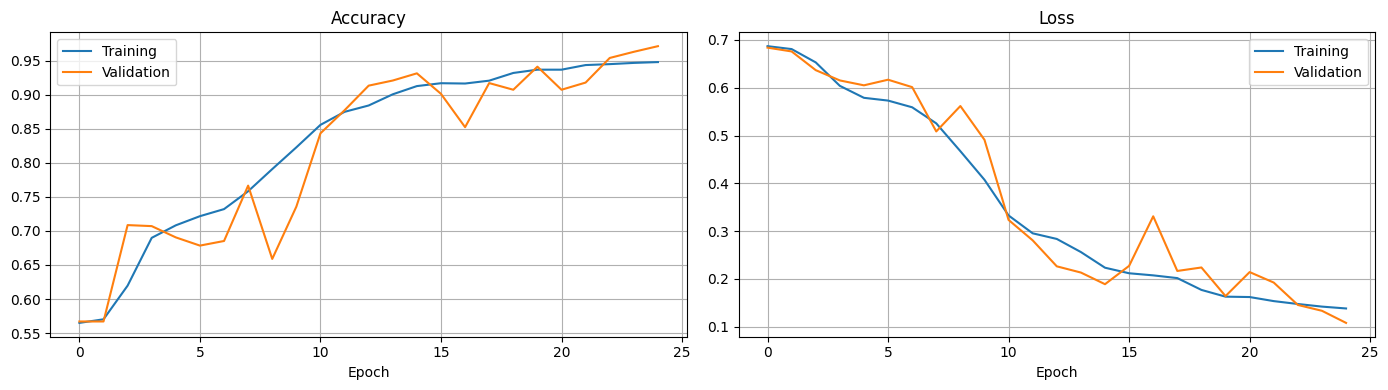

In [37]:
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,4))
    ax1.plot(history.history['accuracy'], label='Training')
    ax1.plot(history.history['val_accuracy'], label='Validation')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(); ax1.grid(True)
    ax2.plot(history.history['loss'], label='Training')
    ax2.plot(history.history['val_loss'], label='Validation')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(); ax2.grid(True)
    plt.tight_layout(); plt.show()

plot_history(history)


In [38]:
print("\n Analysis:")
last_acc = history.history['accuracy'][-1]
last_val_acc = history.history['val_accuracy'][-1]
print(f"Final Training Accuracy: {last_acc:.4f}")
print(f"Final Validation Accuracy: {last_val_acc:.4f}")
print(f"Gap: {last_acc - last_val_acc:.4f}")
print("Overfitting?" , "Yes" if (last_acc - last_val_acc) > 0.15 else "No")
print("Early stopping activated?" , "Yes" if len(history.history['accuracy']) < MAX_EPOCHS else "No")


📊 Analysis:
Final Training Accuracy: 0.9480
Final Validation Accuracy: 0.9714
Gap: -0.0234
Overfitting? No
Early stopping activated? No


In [39]:
test_loss, test_acc, test_precision, test_recall = model.evaluate(test_dataset, verbose=1)
print(f"\nTest Accuracy  : {test_acc:.4f}")
print(f"Test Precision : {test_precision:.4f}")
print(f"Test Recall    : {test_recall:.4f}")


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.9678 - loss: 0.0949 - precision: 0.9509 - recall: 0.9618

Test Accuracy  : 0.9678
Test Precision : 0.9509
Test Recall    : 0.9618


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
Confusion Matrix:
 [[440  13]
 [ 10 252]]


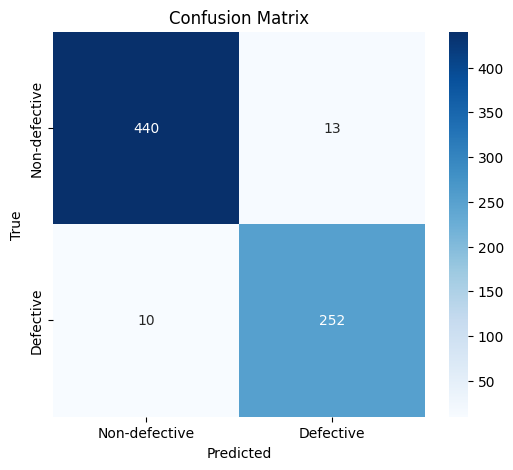


Classification Report:
               precision    recall  f1-score   support

Non-defective       0.98      0.97      0.97       453
    Defective       0.95      0.96      0.96       262

     accuracy                           0.97       715
    macro avg       0.96      0.97      0.97       715
 weighted avg       0.97      0.97      0.97       715


Recall for Defective class: 0.9618
Higher recall means fewer defective items are missed.


In [40]:
probs = model.predict(test_dataset)
preds = (probs.flatten() >= 0.5).astype(int)
true_labels = np.concatenate([y for x,y in test_dataset], axis=0).flatten().astype(int)

cm = confusion_matrix(true_labels, preds)
print("Confusion Matrix:\n", cm)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-defective','Defective'],
            yticklabels=['Non-defective','Defective'])
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:")
print(classification_report(true_labels, preds,
                            target_names=['Non-defective','Defective']))

# Recall importance
defective_recall = cm[1,1]/(cm[1,0]+cm[1,1]) if (cm[1,0]+cm[1,1])>0 else 0
print(f"\nRecall for Defective class: {defective_recall:.4f}")
print("Higher recall means fewer defective items are missed.")


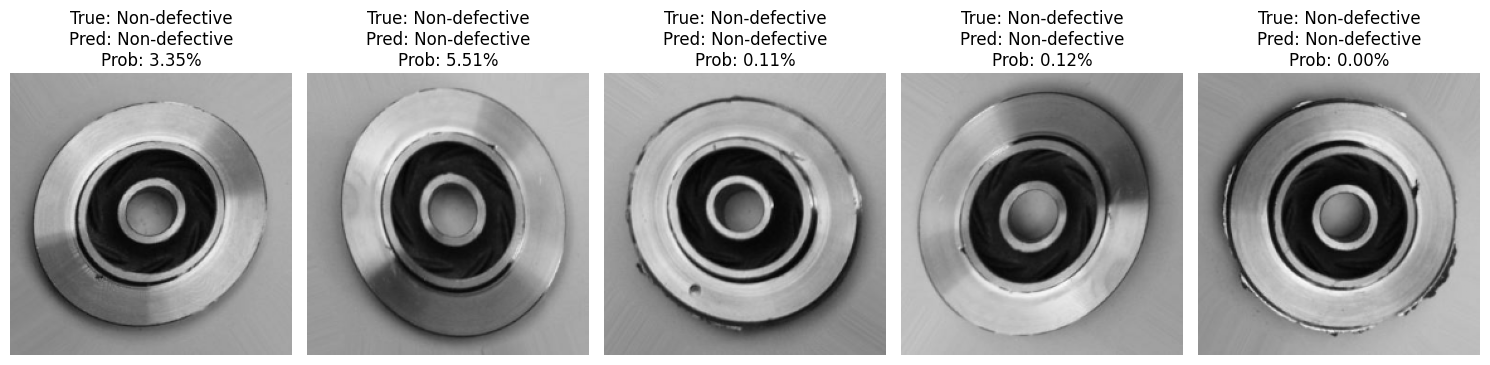

In [41]:
test_images = []
test_labels = []
for images, labels in test_dataset.take(1):
    for i in range(min(5, len(images))):
        test_images.append(images[i].numpy())
        test_labels.append(labels[i].numpy()[0])

plt.figure(figsize=(15,6))
for i in range(len(test_images)):
    plt.subplot(1,5,i+1)
    plt.imshow(test_images[i]/255.0)
    prob = model.predict(np.expand_dims(test_images[i], axis=0), verbose=0)[0][0]
    pred_label = "Defective" if prob>=0.5 else "Non-defective"
    true_label = "Defective" if test_labels[i]==1 else "Non-defective"
    plt.title(f"True: {true_label}\nPred: {pred_label}\nProb: {prob:.2%}")
    plt.axis('off')
plt.tight_layout(); plt.show()

In [44]:

# save in temporary path
temp_path = "/content/casting_defect_detector.keras"
model.save(temp_path)

from google.colab import files
files.download(temp_path)

print("Model download start")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model download start
